# Simulating Non-Hermitian Systems

This notebook presents a minimal non-Hermitian bilayer model in *MoirePy*. Non-Hermiticity is introduced through an angle-dependent in-plane hopping amplitude. For simplicity, the inter-layer hopping (`t_lu = t_ul`) is taken to be symmetric in this example. However, there is no fundamental restriction within the framework, and fully general non-Hermitian systems can be constructed in the same way.


## 1. Setup

We build one lattice instance with open boundary conditions and reuse it throughout.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from moirepy import BilayerMoireLattice, SquareLayer

params = {
    "latticetype": SquareLayer,
    "ll1": 9,
    "ll2": 10,
    "ul1": 10,
    "ul2": 9,
    "n1": 1,
    "n2": 1,
}

lattice = BilayerMoireLattice(**params, pbc=False)
lattice.generate_connections(inter_layer_radius=1.0)

twist angle = 0.1052 rad (6.0256 deg)
181 cells in upper lattice
181 cells in lower lattice


## 2. Direction-Dependent Intra-Layer Hopping

The callable below follows the pair-hopping signature and returns one value per bond.


In [2]:
def anisotropic_hopping(pos_i, pos_j, R, type_i, type_j, lattice, t0=1.0, gamma=0.3):
    # Vectorized bond directions in the lattice frame.
    d = (pos_j + R) - pos_i
    theta = np.arctan2(d[:, 1], d[:, 0])
    return t0 + gamma * np.cos(theta)


## 3. Build a Non-Hermitian Hamiltonian

We set `tlu` and `tul` to different constants to make the Hamiltonian non-Hermitian.


In [3]:
ham = lattice.generate_hamiltonian(
    tll=anisotropic_hopping,
    tuu=anisotropic_hopping,
    tlu=1.0,
    tul=1.0,
    tlself=0.0,
    tuself=0.0,
).toarray()

print("Is the Hamiltonian Hermitian?", np.allclose(ham, ham.conj().T))

Is the Hamiltonian Hermitian? False


## 4. Complex Spectrum

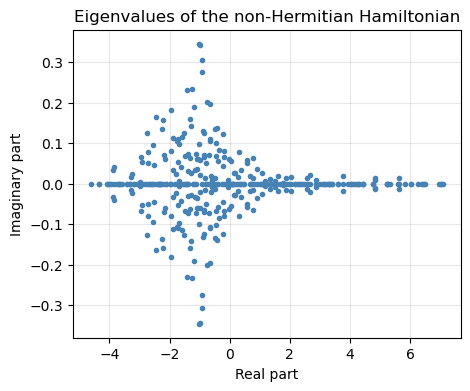

In [4]:
e, v = np.linalg.eig(ham)

plt.figure(figsize=(5, 4))
plt.plot(e.real, e.imag, 'o', color='steelblue', markersize=3)
plt.xlabel('Real part')
plt.ylabel('Imaginary part')
plt.title('Eigenvalues of the non-Hermitian Hamiltonian')
plt.grid(alpha=0.3)

## 5. One Eigenmode (Skin-Effect Style Localization)

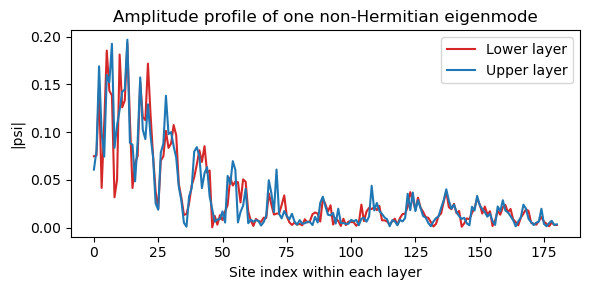

In [5]:
mode = np.argmax(np.abs(e.imag))
amp = np.abs(v[:, mode])

n_lower = lattice.lower_lattice.points.shape[0]

plt.figure(figsize=(6, 3))
plt.plot(amp[:n_lower], label='Lower layer', color='tab:red')
plt.plot(amp[n_lower:], label='Upper layer', color='tab:blue')
plt.xlabel('Site index within each layer')
plt.ylabel('|psi|')
plt.title('Amplitude profile of one non-Hermitian eigenmode')
plt.legend()
plt.tight_layout()

## 6. Spatial Eigenmode Amplitude on the Lattice

This reproduces the geometric view from section 7 in `custom_hoppings.ipynb`:
we color each lattice site by the eigenmode amplitude.


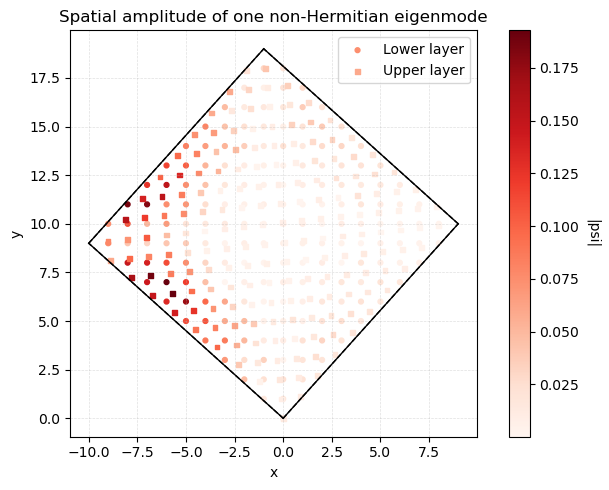

In [6]:
# Spatial plot of one eigenmode on the moire geometry
mode = np.argmax(np.abs(e.imag))

n_lower = lattice.lower_lattice.points.shape[0]
amp_lower = np.abs(v[:n_lower, mode])
amp_upper = np.abs(v[n_lower:, mode])

plt.figure(figsize=(7, 5))

nx = lattice.n1
ny = lattice.n2
mlv1 = lattice.mlv1
mlv2 = lattice.mlv2

# Draw simulation supercell boundary
plt.plot([0, nx * mlv1[0]], [0, nx * mlv1[1]], 'k', linewidth=1)
plt.plot([0, ny * mlv2[0]], [0, ny * mlv2[1]], 'k', linewidth=1)
plt.plot(
    [nx * mlv1[0], nx * mlv1[0] + ny * mlv2[0]],
    [nx * mlv1[1], nx * mlv1[1] + ny * mlv2[1]],
    'k',
    linewidth=1,
)
plt.plot(
    [ny * mlv2[0], nx * mlv1[0] + ny * mlv2[0]],
    [ny * mlv2[1], nx * mlv1[1] + ny * mlv2[1]],
    'k',
    linewidth=1,
)

# Draw one moire unit cell
plt.plot([0, mlv1[0]], [0, mlv1[1]], 'k--', linewidth=1)
plt.plot([0, mlv2[0]], [0, mlv2[1]], 'k--', linewidth=1)
plt.plot([mlv1[0], mlv1[0] + mlv2[0]], [mlv1[1], mlv1[1] + mlv2[1]], 'k--', linewidth=1)
plt.plot([mlv2[0], mlv1[0] + mlv2[0]], [mlv2[1], mlv1[1] + mlv2[1]], 'k--', linewidth=1)

# Plot lower and upper layer sites colored by |psi|
sc_lower = plt.scatter(
    lattice.lower_lattice.points[:, 0],
    lattice.lower_lattice.points[:, 1],
    c=amp_lower,
    cmap='Reds',
    s=12,
    label='Lower layer',
)

plt.scatter(
    lattice.upper_lattice.points[:, 0],
    lattice.upper_lattice.points[:, 1],
    c=amp_upper,
    cmap='Reds',
    s=12,
    marker='s',
    label='Upper layer',
)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Spatial amplitude of one non-Hermitian eigenmode')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.legend(loc='best')

cbar = plt.colorbar(sc_lower)
cbar.set_label('|psi|', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


## Summary

- Non-Hermiticity is easy to model in MoirePy through asymmetric hopping choices.
- The resulting spectrum can become complex.
- Eigenmode amplitudes can show strong boundary/localization effects.
